In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
import warnings
import sys
sys.path.insert(0,'../../')
from CB68.data_dict import data_dict

from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import skycoord_to_pixel
from astropy.coordinates import SkyCoord
import astropy.constants as const
au = const.au.cgs.value
pc = const.pc.cgs.value

In [2]:
def crop_image(image, center, width_au, au_per_pix):
    width = int(width_au/au_per_pix)
    return image[center[0]-width//2:center[0]+width//2, center[0]-width//2:center[0]+width//2]

def rotate_image(image, posang):
    image = ndimage.rotate(image, posang, reshape=False, axes=(1, 0))
    image = np.nan_to_num(image, nan=0)
    return image

def radial_intensity(image_array, center, width):
  if center is None:
    center = image_array.shape[1]//2
  radial_profile = np.mean(image_array[:, center-width//2:center+width//2], axis=1)
  return radial_profile

In [3]:
distance_pc = 140
crop_sizeau = 80

In [4]:
fits_data = data_dict["1.3_edisk"]
with fits.open(fits_data["fname"]) as hdul:
    data = hdul[0].data
    header = hdul[0].header
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        wcs = WCS(header=header)

In [5]:
au_per_pix_edisk = abs(header['CDELT1'])/180*np.pi*distance_pc*pc/au

In [6]:
edisk_image = crop_image(data, [2996, 2996], crop_sizeau, au_per_pix_edisk)
edisk_image = rotate_image(edisk_image, 45)
i_r = radial_intensity(edisk_image, None, 10)
r_axis = np.linspace(-(crop_sizeau//2), crop_sizeau//2, len(i_r), endpoint=True)

In [7]:
np.savez("edisk_radial.npz",
        r_axis=r_axis, 
        i_r=i_r,
        beam_axis=np.array([header['BMAJ']*3600, header['BMIN']*3600]),
        beam_pa=np.array([header['BPA']]))

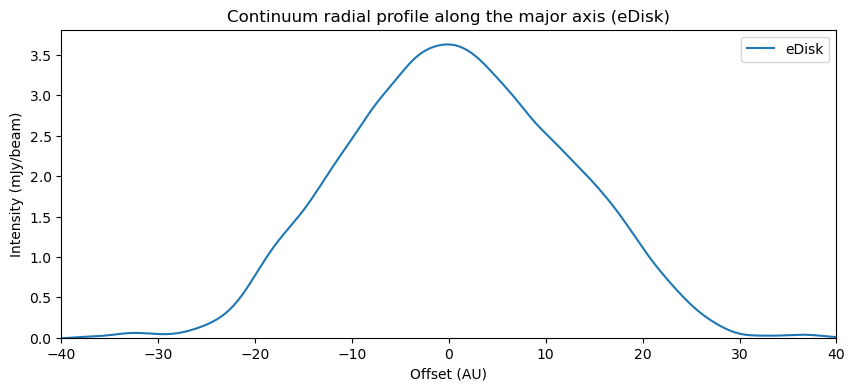

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(r_axis, i_r*1e3, label="eDisk")
plt.xlabel("Offset (AU)")
plt.ylabel("Intensity (mJy/beam)")
plt.title("Continuum radial profile along the major axis (eDisk)")
plt.xlim((-(crop_sizeau//2), crop_sizeau//2))
plt.ylim(bottom=0)
plt.legend()
plt.savefig("edisk_radial.pdf", transparent=True)

In [9]:
plt.close("all")